# Data Creation

## 1. Imports and Setup

Add the project root to `sys.path` so that `src/` and `config.py` are importable. Output directories are created here to avoid repeated checks in downstream cells.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, os.path.abspath('..'))

import config
from src.features import load_data, merge_data, drop_null_cols, convert_datetime
from src.utils import full_value_counts

Path(config.PLOTS_PATH).mkdir(parents=True, exist_ok=True)
Path(config.RESULTS_PATH).mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load Data

Load the raw IEEE-CIS transaction and identity CSVs.

In [2]:
df_transaction, df_identity = load_data(config.TRANSACTION_PATH, config.IDENTITY_PATH)

print('transaction:', df_transaction.shape)
print('identity:   ', df_identity.shape)

transaction: (590540, 394)
identity:    (144233, 41)


In [3]:
df_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


## 3. Merge

Left join identity onto transactions on `TransactionID`. The identity table covers a subset of transactions; the left join preserves all transactions and leaves identity columns null where no match exists.

In [ ]:
df = merge_data(df_transaction, df_identity)

transaction shape: (590540, 394)
identity shape:    (144233, 41)
merged shape:      (590540, 434)
rows without identity data: 449,730


(590540, 434)

In [6]:
n_total = len(df)
n_with_id = df['DeviceType'].notna().sum()
n_without_id = df['DeviceType'].isna().sum()
pct_missing = n_without_id / n_total * 100

n_fraud_no_id = df[df['DeviceType'].isna()][config.TARGET].sum()
fraud_rate_with_id = df[df['DeviceType'].notna()][config.TARGET].mean() * 100
fraud_rate_no_id = df[df['DeviceType'].isna()][config.TARGET].mean() * 100

print(f'total rows:              {n_total:,}')
print(f'rows with identity:      {n_with_id:,}')
print(f'rows without identity:   {n_without_id:,}')
print(f'pct missing identity:    {pct_missing:.1f}%')
print(f'fraud in no-id rows:     {n_fraud_no_id:,}')
print(f'fraud rate (with id):    {fraud_rate_with_id:.2f}%')
print(f'fraud rate (without id): {fraud_rate_no_id:.2f}%')

total rows:              590,540
rows with identity:      140,810
rows without identity:   449,730
pct missing identity:    76.2%
fraud in no-id rows:     9,452
fraud rate (with id):    7.96%
fraud rate (without id): 2.10%


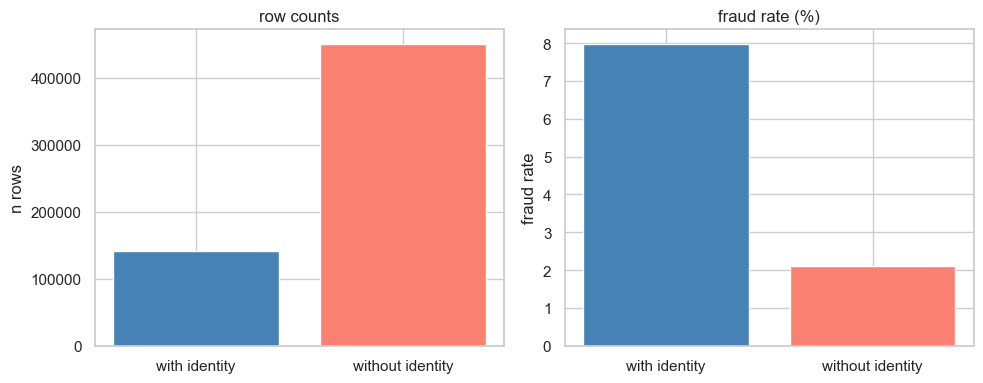

In [8]:
labels = ['with identity', 'without identity']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, [n_with_id, n_without_id], color=['steelblue', 'salmon'])
axes[0].set_title('row counts')
axes[0].set_ylabel('n rows')

axes[1].bar(labels, [fraud_rate_with_id, fraud_rate_no_id], color=['steelblue', 'salmon'])
axes[1].set_title('fraud rate (%)')
axes[1].set_ylabel('fraud rate')

fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'identity_missingness.png')
plt.show()
plt.close()

Rows with missing identity data are retained. Missingness is treated as signal and handled natively by gradient boosting models during training. Will create a feature for this. Research on Kaggle indicates:

- Transactions WITH identity data — web or app based transactions where device fingerprinting was possible
- Transactions WITHOUT identity data — transactions processed through a different channel, likely point of sale, phone orders, or third party processors where Vesta's identity collection wasn't active

## 4. Null Analysis

Inspect null rates across all columns. Columns above `NULL_THRESHOLD` (80%) are dropped — they carry too little signal to be useful and would complicate imputation.

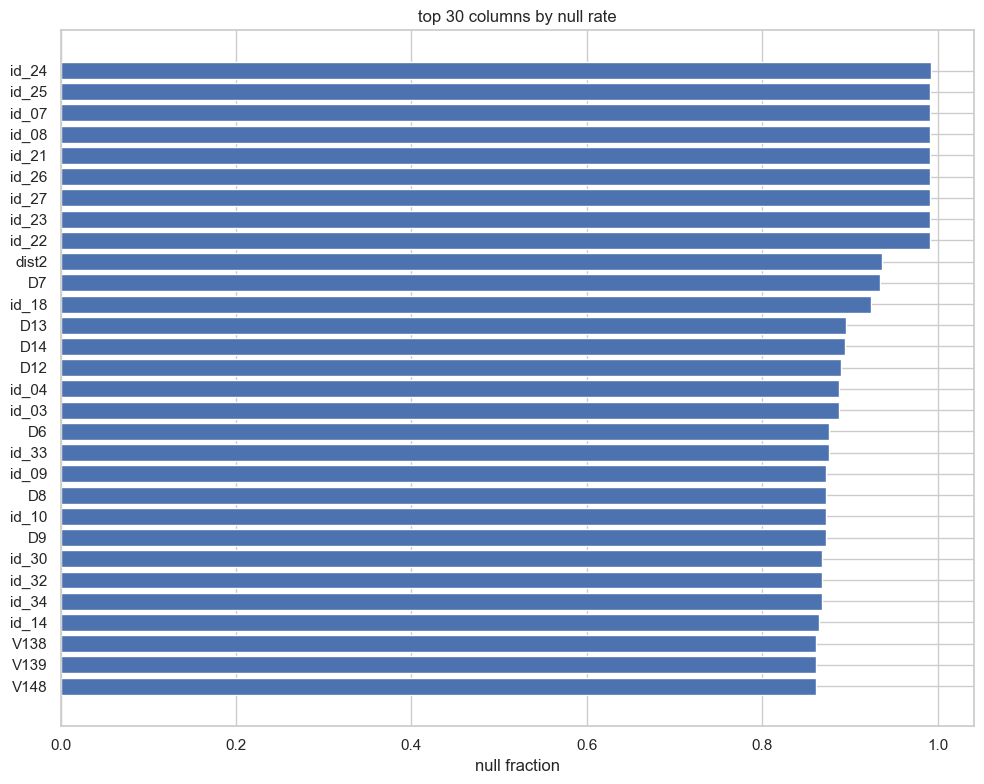

In [10]:
null_pct = df.isnull().mean().sort_values(ascending=False)
top30 = null_pct.head(30)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top30.index[::-1], top30.values[::-1])
ax.set_xlabel('null fraction')
ax.set_title('top 30 columns by null rate')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'null_analysis.png')
plt.show()
plt.close()

In [11]:
df = drop_null_cols(df, threshold=config.NULL_THRESHOLD); df.shape

columns dropped:   74
columns remaining: 360


(590540, 360)

## 5. DateTime Conversion

`TransactionDT` is seconds elapsed from a reference date (~2017-11-30). Convert to datetime and extract `hour_of_day` and `day_of_week` as time features.

In [12]:
df = convert_datetime(df)
df[['TransactionDT', 'hour_of_day', 'day_of_week']].head(10)

,TransactionDT,hour_of_day,day_of_week
0,2017-12-01 00:00:00,0,4
1,2017-12-01 00:00:01,0,4
2,2017-12-01 00:01:09,0,4
3,2017-12-01 00:01:39,0,4
4,2017-12-01 00:01:46,0,4
5,2017-12-01 00:01:50,0,4
6,2017-12-01 00:02:02,0,4
7,2017-12-01 00:02:09,0,4
8,2017-12-01 00:02:15,0,4
9,2017-12-01 00:02:16,0,4


## 6. Target Analysis

The dataset is heavily imbalanced. Confirm the fraud rate and verify no rows were dropped during cleaning.

            cnt      pct
isFraud                 
0        569877  0.96501
1         20663  0.03499


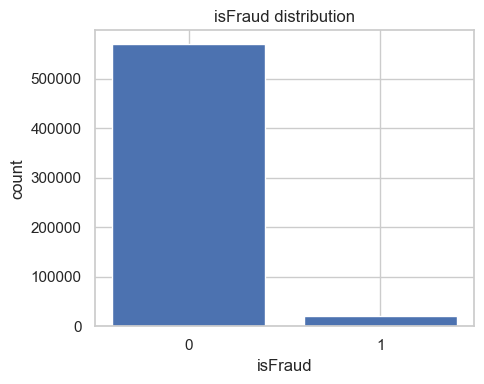

fraud rate: 3.50%
rows dropped: 0 — no rows have been removed at this stage


In [14]:
vc = full_value_counts(df, config.TARGET)
print(vc)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(vc.index.astype(str), vc['cnt'])
ax.set_title(f'{config.TARGET} distribution')
ax.set_xlabel(config.TARGET)
ax.set_ylabel('count')
fig.tight_layout()
fig.savefig(config.PLOTS_PATH / 'target_distribution.png')
plt.show()
plt.close()

fraud_rate = df[config.TARGET].mean() * 100
print(f'fraud rate: {fraud_rate:.2f}%')
print('rows dropped: 0 — no rows have been removed at this stage')

## 7. Save

Write the cleaned dataframe to parquet for use in downstream notebooks.

In [15]:
out = Path(config.RESULTS_PATH) / 'data_clean.parquet'
df.to_parquet(out, index=False)
print(f'saved to {out}')
print(f'final shape: {df.shape}')

saved to c:\Users\timot\fraud_model\fraud_model\outputs\results\data_clean.parquet
final shape: (590540, 362)
